# Exploración y estacionariedad de la TRM diaria

Primera etapa del análisis de la Tasa Representativa del Mercado (TRM), que corresponde a la cantidad de pesos colombianos por un dólar de los Estados Unidos (Banco de la República, s.f.-a). En este notebook se caracteriza la serie diaria entre noviembre de 1991 y agosto de 2026, con su tendencia, sus patrones periódicos, sus atípicos y sus cambios de régimen, y se determina la transformación que la vuelve estacionaria, que es el punto de partida del modelado de la etapa siguiente.

| Notebook | Etapa |
|---|---|
| **01 · Exploración de la serie diaria** | Calidad, patrones periódicos, atípicos, estacionariedad y ACF/PACF |
| 02 · Modelado mensual | Identificación, estimación, diagnóstico y volatilidad (ARIMA + GARCH) |
| 03 · Pronóstico | Evaluación frente a la caminata aleatoria y pronóstico a 12 meses |

**Fuente de datos:** Banco de la República (2026), Portal de Estadísticas Económicas. Serie diaria de la TRM.

---
# Preparación del entorno

Las funciones que se repiten entre notebooks, como la carga de los datos y las pruebas de estacionariedad, se encuentran en el paquete `trm` del repositorio (carpeta `src/trm`). Las pruebas estadísticas se apoyan en statsmodels (Seabold & Perktold, 2010).

In [1]:
# En Google Colab el paquete del proyecto se instala desde GitHub; en el entorno local ya queda disponible con uv sync
import importlib.util
if importlib.util.find_spec("trm") is None:
    get_ipython().run_line_magic("pip", "install -q git+https://github.com/Juanhv24/Time-Series-Colombia.git")

In [2]:
import warnings

# Manejo de datos
import numpy as np
import pandas as pd
from scipy import stats

# Visualización
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Series de tiempo
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Paquete del proyecto
from trm import config, datos, pruebas
from trm.graficos import estilo, guardar, AZUL, ROJO, VERDE

estilo()
# statsmodels registra sus propios filtros al importarse, por lo que los avisos se silencian después de las importaciones
warnings.filterwarnings("ignore")

### Carga de la serie

La TRM es una serie diaria con dos columnas, fecha y valor, que se descarga del portal del Banco de la República. La función `datos.cargar_trm` lee el archivo del repositorio y, si no está disponible, lo descarga desde GitHub, de modo que el notebook se ejecuta igual en un entorno local y en Google Colab.

In [3]:
serie = datos.cargar_trm()
trm = serie.rename_axis("fecha").reset_index()

print(f"Rango de la serie: {trm['fecha'].min().date()} a {trm['fecha'].max().date()}")
print(f"Número de observaciones: {len(trm)}")
trm.head()

Rango de la serie: 1991-11-27 a 2026-08-28
Número de observaciones: 12694


,fecha,trm
0,1991-11-27,693.32
1,1991-11-28,693.99
2,1991-11-29,694.70
3,1991-11-30,694.70
4,1991-12-01,643.42


### Validación de calidad de datos

In [4]:
calendario = pd.date_range(trm["fecha"].min(), trm["fecha"].max(), freq="D")

print(f"Duplicados: {trm['fecha'].duplicated().sum()}")
print(f"Nulos: {trm['trm'].isna().sum()}")
print(f"Días del calendario sin dato: {len(calendario.difference(trm['fecha']))}")

Duplicados: 0
Nulos: 0
Días del calendario sin dato: 0


**Interpretación:** El análisis de calidad de datos nos permite determinar que la serie no presenta fechas duplicadas ni valores faltantes, y que además cubre la totalidad de los días del calendario, incluidos sábados, domingos y festivos, por lo que en este caso no es requerido usar procedimientos de imputación ni depuración adicionales. Sin embargo, que existan datos en días sin negociación ya anticipa una característica de la forma en que se publica la serie, la cual se examina en la sección 2.1.

---
# 1. Identificación de los elementos básicos

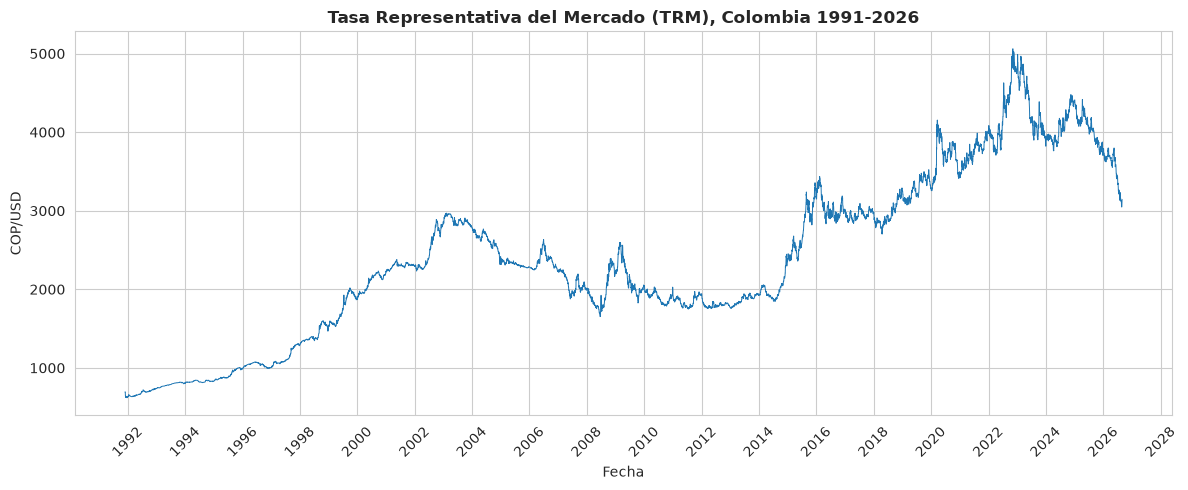

In [5]:
fig, ax = plt.subplots()
ax.plot(trm["fecha"], trm["trm"], color=AZUL, linewidth=0.7)
ax.set_title("Tasa Representativa del Mercado (TRM), Colombia 1991-2026")
ax.set_xlabel("Fecha")
ax.set_ylabel("COP/USD")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
guardar(fig, "01_trm_nivel.png")
plt.show()

**Interpretación:** En la gráfica de la serie podemos observar una tendencia creciente de largo plazo, que parte de un nivel inferior a 1000 COP/USD a comienzos de los años noventa y alcanza su máximo histórico, superior a 5000 COP/USD, a finales de 2022. A pesar de esto, el comportamiento de la serie no es monótono, ya que se identifican episodios de depreciación acelerada seguidos de correcciones. Si bien el gráfico por sí solo no permite determinar las causas de estos episodios, el Banco de la República documenta eventos que contribuyen a explicarlos, como la crisis de las empresas puntocom, la quiebra de Lehman Brothers en 2008, la caída del precio internacional del petróleo en 2014 y la pandemia de 2020 (Banco de la República, s.f.-b, s.f.-c), por lo que la correspondencia entre estos eventos y los tramos de depreciación observados nos permite construir una hipótesis razonable sobre el origen de los movimientos. Para finalizar, debido a que el nivel de la serie está dominado por su componente tendencial, resulta difícil identificar otros patrones subyacentes, por lo que es necesario calcular la variación porcentual diaria, o retorno diario, con la finalidad de remover dicho componente de tendencia.

In [6]:
# Retorno diario de la TRM, en porcentaje
trm["retorno_diario"] = trm["trm"].pct_change() * 100
trm.tail(10)

,fecha,trm,retorno_diario
12684,2026-08-19,3098.79,-0.954405
12685,2026-08-20,3053.48,-1.462184
12686,2026-08-21,3062.96,0.310465
12687,2026-08-22,3048.12,-0.484499
12688,2026-08-23,3048.12,0.000000
12689,2026-08-24,3048.12,0.000000
12690,2026-08-25,3056.51,0.275252
12691,2026-08-26,3081.67,0.823161
12692,2026-08-27,3118.24,1.186694
12693,2026-08-28,3144.28,0.835086


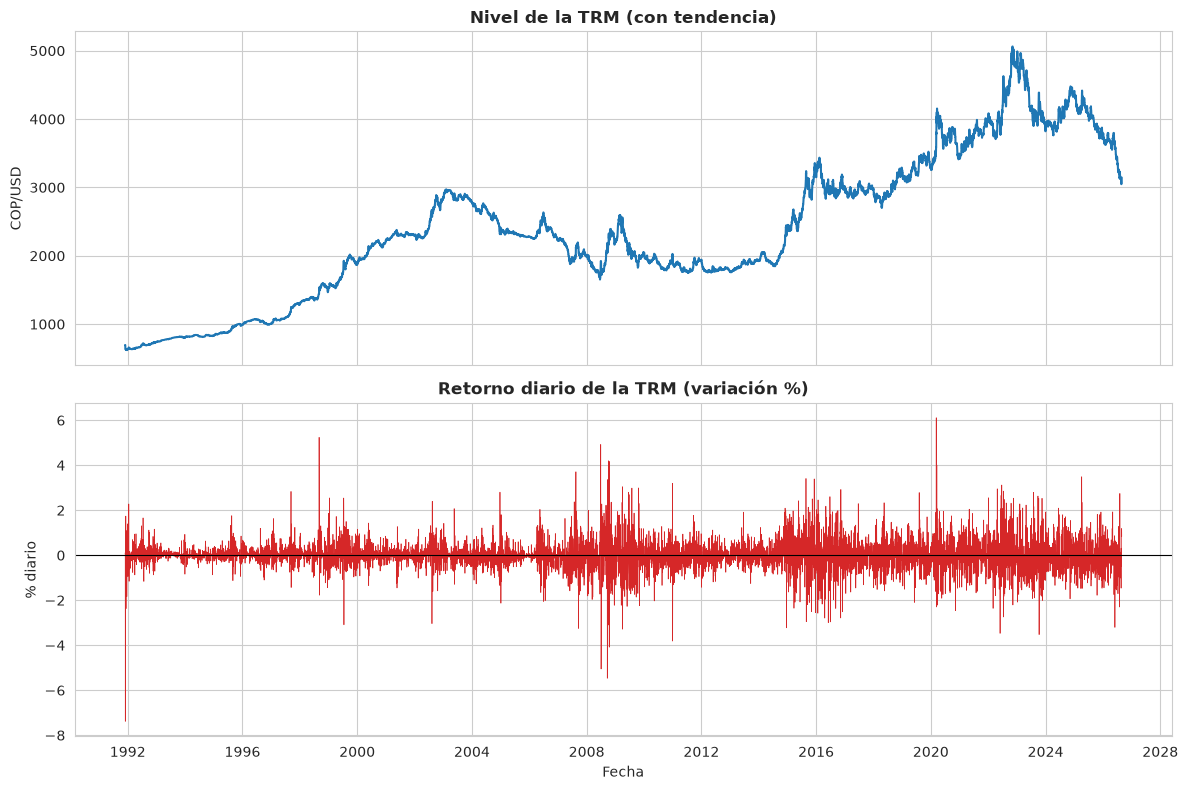

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(trm["fecha"], trm["trm"], color=AZUL)
axes[0].set_title("Nivel de la TRM (con tendencia)")
axes[0].set_ylabel("COP/USD")

axes[1].plot(trm["fecha"], trm["retorno_diario"], color=ROJO, linewidth=0.5)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Retorno diario de la TRM (variación %)")
axes[1].set_ylabel("% diario")
axes[1].set_xlabel("Fecha")

plt.tight_layout()
guardar(fig, "02_trm_nivel_vs_retorno.png")
plt.show()

**Interpretación:** Observando las dos gráficas podemos concluir que el contraste entre ambos paneles es marcado, ya que por un lado la TRM en nivel exhibe un desplazamiento sistemático de su media a lo largo del período, mientras que por otro lado el retorno diario oscila en torno a cero durante toda la serie, con una distribución que puede ser comparable entre los extremos inicial y final. A pesar de esto, en el panel del retorno se observan agrupamientos de alta variabilidad en tramos específicos, como en el año 2020, y estos comportamientos corresponden al agrupamiento de volatilidad documentado como propiedad recurrente de las series financieras (Cont, 2001).

---
# 2. Análisis gráfico y exploratorio

## 2.1 Búsqueda de patrones estacionales

     mediana     Q1     Q3  pct_cero    IQR
mes                                        
1        0.0 -0.079  0.116    38.894  0.195
2        0.0 -0.132  0.103    31.041  0.235
3        0.0 -0.080  0.088    33.548  0.168
4        0.0 -0.151  0.099    33.524  0.250
5        0.0 -0.074  0.134    35.115  0.208
6        0.0 -0.094  0.129    36.190  0.223
7        0.0 -0.116  0.115    34.747  0.231
8        0.0 -0.084  0.182    34.196  0.266
9        0.0 -0.115  0.166    30.784  0.281
10       0.0 -0.119  0.130    33.112  0.249
11       0.0 -0.062  0.090    39.003  0.152
12       0.0 -0.163  0.050    35.207  0.213

Retornos exactamente cero: 4397 de 12693 (34.6%)


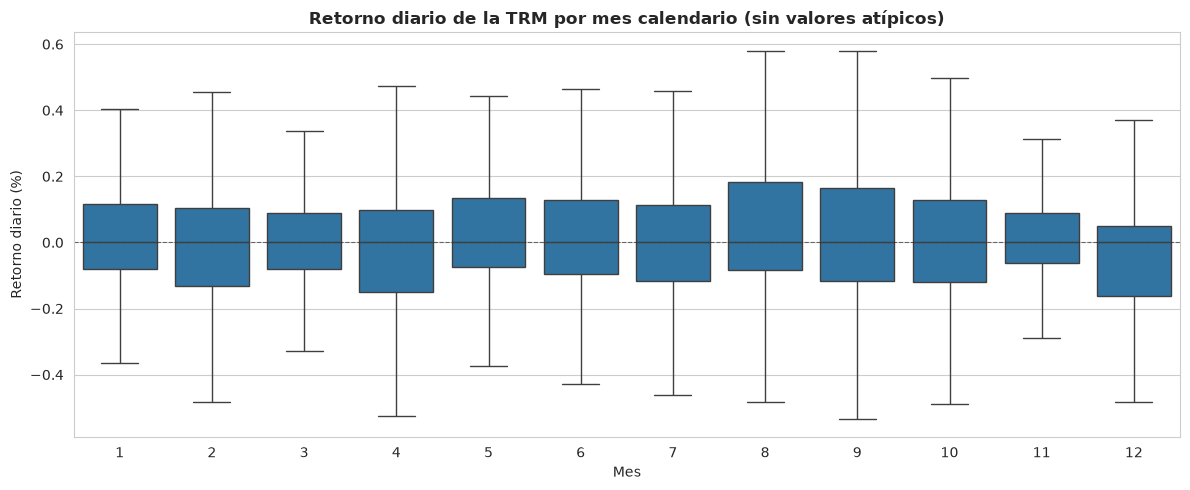

In [8]:
trm["mes"] = trm["fecha"].dt.month
retornos = trm.dropna(subset=["retorno_diario"])

# Resumen numérico por mes
resumen_mes = retornos.groupby("mes")["retorno_diario"].agg(
    mediana="median",
    Q1=lambda s: s.quantile(0.25),
    Q3=lambda s: s.quantile(0.75),
    pct_cero=lambda s: (s == 0).mean() * 100,
).round(3)
resumen_mes["IQR"] = (resumen_mes["Q3"] - resumen_mes["Q1"]).round(3)
print(resumen_mes.to_string())

ceros = (retornos["retorno_diario"] == 0).sum()
print(f"\nRetornos exactamente cero: {ceros} de {len(retornos)} ({ceros / len(retornos) * 100:.1f}%)")

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=retornos, x="mes", y="retorno_diario", showfliers=False, color=AZUL, ax=ax)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("Retorno diario de la TRM por mes calendario (sin valores atípicos)")
ax.set_xlabel("Mes")
ax.set_ylabel("Retorno diario (%)")
plt.tight_layout()
guardar(fig, "03_retorno_por_mes.png")
plt.show()

**Interpretación:** Una vez removido el componente de tendencia se facilita la búsqueda de patrones estacionales que antes estaban ocultos, y en este caso se hizo uso de diagramas de caja del retorno diario agrupado por mes calendario. En la tabla y en la gráfica podemos observar que la mediana es exactamente cero en los doce meses, mientras que la amplitud de las cajas varía de forma moderada entre 0.152 y 0.281 puntos porcentuales, con los extremos en noviembre y septiembre respectivamente, sin que la secuencia siga un patrón de calendario reconocible. Teniendo en cuenta lo anterior, no es posible encontrar evidencia de un efecto calendario mensual en la TRM, resultado que coincide con la ausencia de mecanismos administrativos de periodicidad mensual que puedan inducir estacionalidad en la tasa de cambio.

A pesar de esto, que las medianas sean exactamente cero y no simplemente próximas a cero es un resultado que requiere explicación, ya que en la salida observamos que el 34.6 % de los retornos de la serie vale exactamente cero. Además, con un tercio de la masa concentrada en un valor único, la mediana de cualquier submuestra mensual cae necesariamente en cero, independientemente del mes que se esté validando, por lo que estas medianas no aportan información relevante sobre la estacionalidad mensual. Por ende, el origen de esta concentración de ceros puede derivar del mecanismo de cálculo de la serie, ya que la TRM se calcula con base en las operaciones registradas por los intermediarios del mercado cambiario durante el día hábil inmediatamente anterior, y para los sábados, domingos y festivos aplica la TRM vigente del día hábil inmediatamente siguiente (Banco de la República, 2018). Esta regla administrativa debería producir un comportamiento diferenciado por día de la semana, verificable empíricamente.

            mediana     Q1     Q3  pct_cero    IQR
dia_semana                                        
Lunes          0.00  0.000  0.000   100.000  0.000
Martes         0.00 -0.123  0.199    26.751  0.322
Miércoles      0.02 -0.250  0.333     2.372  0.583
Jueves         0.00 -0.285  0.292     2.481  0.577
Viernes        0.00 -0.267  0.276     5.788  0.543
Sábado         0.00 -0.293  0.233     5.185  0.526
Domingo        0.00  0.000  0.000    99.945  0.000


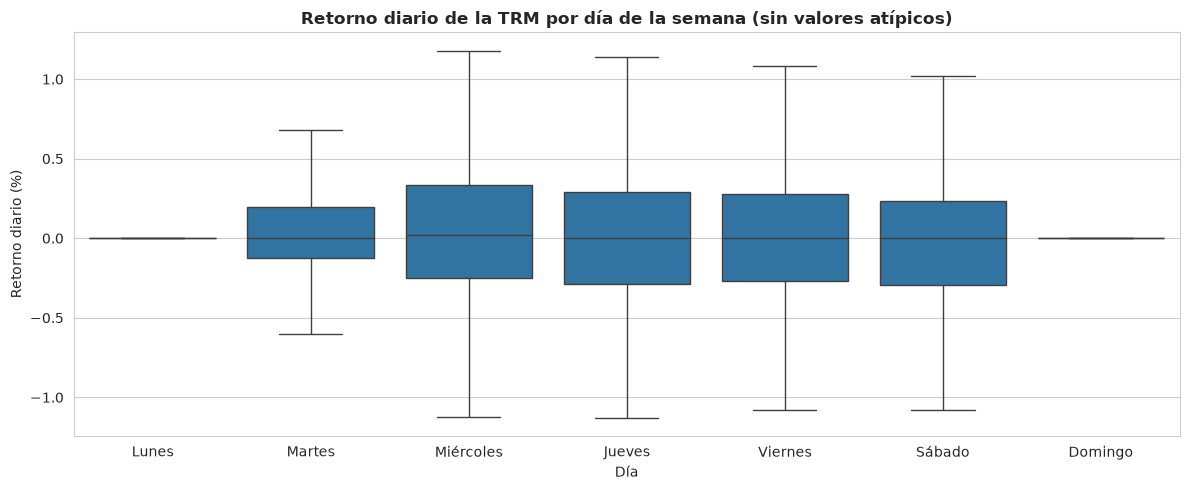

In [9]:
dias_es = {"Monday": "Lunes", "Tuesday": "Martes", "Wednesday": "Miércoles", "Thursday": "Jueves",
           "Friday": "Viernes", "Saturday": "Sábado", "Sunday": "Domingo"}
orden_dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]

trm["dia_semana"] = trm["fecha"].dt.day_name().map(dias_es)
retornos = trm.dropna(subset=["retorno_diario"])

# Resumen numérico por día
resumen_dia = retornos.groupby("dia_semana")["retorno_diario"].agg(
    mediana="median",
    Q1=lambda s: s.quantile(0.25),
    Q3=lambda s: s.quantile(0.75),
    pct_cero=lambda s: (s == 0).mean() * 100,
).reindex(orden_dias).round(3)
resumen_dia["IQR"] = (resumen_dia["Q3"] - resumen_dia["Q1"]).round(3)
print(resumen_dia.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=retornos, x="dia_semana", y="retorno_diario", order=orden_dias,
            showfliers=False, color=AZUL, ax=ax)
ax.set_title("Retorno diario de la TRM por día de la semana (sin valores atípicos)")
ax.set_xlabel("Día")
ax.set_ylabel("Retorno diario (%)")
plt.tight_layout()
guardar(fig, "04_retorno_por_dia_semana.png")
plt.show()

**Interpretación:** Continuando con la idea descrita previamente, en el gráfico por día observamos que la semana no tiene un comportamiento homogéneo. Por un lado, domingo y lunes aparecen como líneas planas, sin cajas ni bigotes visibles, ya que la totalidad de sus retornos se concentra en cero. Por otro lado, el martes presenta una caja notoriamente más angosta que el resto, con un rango intercuartílico de 0.322 frente a valores entre 0.526 y 0.583 en los demás días. Finalmente, miércoles, jueves, viernes y sábado muestran distribuciones similares entre sí, centradas en torno a cero.

Los patrones descritos se derivan de la regla de publicación mencionada en el análisis por mes y no de un comportamiento económico como tal. A partir de esta regla, para sábados, domingos y festivos aplica la TRM vigente del día hábil inmediatamente siguiente (Banco de la República, 2018), de tal forma que sábado, domingo y lunes comparten el mismo valor, que es el certificado para el lunes. Al ser idénticos, los retornos de domingo y lunes resultan nulos por construcción, mientras que la variación que se observa el sábado corresponde en realidad al cambio entre dos valores consecutivos de la TRM, es decir, a una jornada completa de negociación. El caso del martes responde al mismo mecanismo, ya que cuando el lunes es festivo el valor permanece constante un día más, situación que ocurre en el 26.8 % de los martes de la serie y que comprime su rango intercuartílico. Finalmente, esta regularidad es un artefacto de calendario administrativo y no estacionalidad en sentido económico, distinción que condiciona tanto la lectura del componente estacional como la detección de atípicos en las secciones siguientes.

## 2.2 Descomposición de la serie

Para la descomposición de la serie se optó por un modelo multiplicativo, debido a que la amplitud de las fluctuaciones crece proporcionalmente con su nivel. Si se empleara un modelo aditivo se estaría asumiendo que la amplitud es constante, lo cual es un supuesto que la serie no satisface.

In [10]:
resultado_365 = seasonal_decompose(trm["trm"], model="multiplicative", period=365)
resultado_7 = seasonal_decompose(trm["trm"], model="multiplicative", period=7)

print(f"Rango estacional con período 365: {resultado_365.seasonal.min():.4f} a {resultado_365.seasonal.max():.4f}")
print(f"Rango estacional con período 7:   {resultado_7.seasonal.min():.4f} a {resultado_7.seasonal.max():.4f}")

# Número de observaciones que se promedian para estimar cada índice estacional
print()
for periodo, resultado in [(365, resultado_365), (7, resultado_7)]:
    sin_tendencia = (trm["trm"] / resultado.trend).dropna()
    obs_por_indice = sin_tendencia.groupby(sin_tendencia.index % periodo).size()
    print(f"Período {periodo:>3}: {len(trm) // periodo:>5} ciclos completos | "
          f"{obs_por_indice.min()}-{obs_por_indice.max()} observaciones por índice estacional")

Rango estacional con período 365: 0.9794 a 1.0162
Rango estacional con período 7:   0.9996 a 1.0004

Período 365:    34 ciclos completos | 33-34 observaciones por índice estacional
Período   7:  1813 ciclos completos | 1812-1813 observaciones por índice estacional


**Interpretación:** En la salida podemos observar que el componente estacional estimado con período 365 abarca un rango considerablemente más amplio que el estimado con período 7. A pesar de esto, una mayor amplitud no valida por sí sola la elección del período, ya que el criterio que se adopta en este trabajo se apoya en cuántas repeticiones por ciclo quedan disponibles para la estimación. Para validarlo se tuvo en cuenta que `seasonal_decompose` calcula cada índice estacional promediando las observaciones sin tendencia que ocupan la misma posición dentro del ciclo, y a partir de esto se obtuvo que con período 7 cada índice resulta del promedio de unas 1813 observaciones, mientras que con período 365 se promedian apenas 34, lo que equivale a una relación cercana a 53 a 1. Por otro lado, con tan pocas repeticiones el promedio no alcanza a estabilizarse y el componente resultante recoge en gran parte el ruido de estimación y no un patrón anual real. Finalmente, a esto se suma que el ciclo semanal cuenta con un mecanismo documentado, que es la regla de publicación verificada en la sección 2.1, mientras que para un ciclo anual no se identifica ningún mecanismo equivalente en una tasa de cambio de libre flotación, por lo que se opta por el período 7.

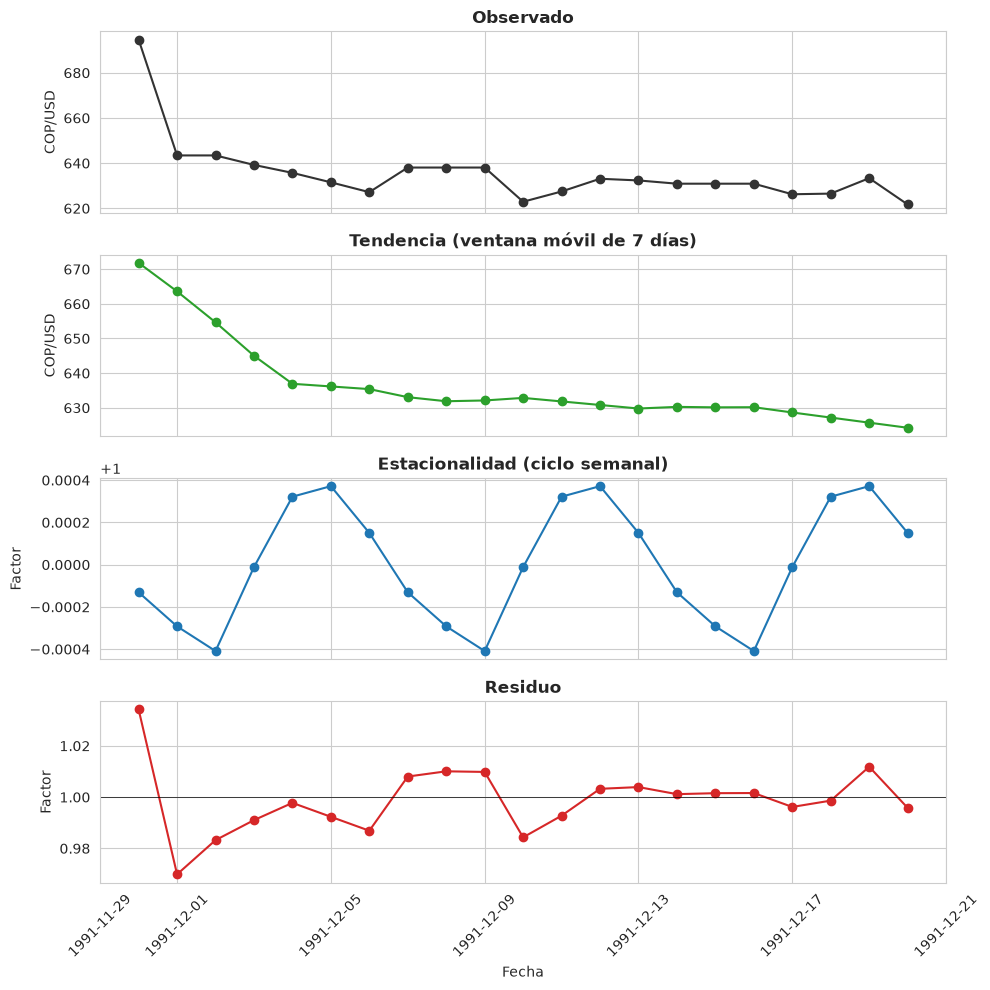

In [11]:
# Zoom a tres semanas para ver la forma real del ciclo semanal
ventana = slice(3, 24)
fechas_zoom = trm["fecha"].iloc[ventana]

fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
componentes = [
    (trm["trm"], "Observado", "COP/USD", "#333333"),
    (resultado_7.trend, "Tendencia (ventana móvil de 7 días)", "COP/USD", VERDE),
    (resultado_7.seasonal, "Estacionalidad (ciclo semanal)", "Factor", AZUL),
    (resultado_7.resid, "Residuo", "Factor", ROJO),
]
for ax, (valores, titulo, unidad, color) in zip(axes, componentes):
    ax.plot(fechas_zoom, valores.iloc[ventana], color=color, marker="o")
    ax.set_title(titulo)
    ax.set_ylabel(unidad)
axes[3].axhline(1, color="black", linewidth=0.5)
axes[3].set_xlabel("Fecha")

plt.xticks(rotation=45)
plt.tight_layout()
guardar(fig, "05_descomposicion_zoom.png")
plt.show()

**Interpretación:** Una vez definidos el modelo y el período, en la gráfica de descomposición podemos observar el comportamiento de cada uno de los componentes. Por un lado, la tendencia reproduce casi exactamente la trayectoria del panel observado, lo que nos permite determinar que una ventana móvil de 7 días resulta insuficiente para estimar una tendencia de largo plazo, por ende, para ese propósito la gráfica de la sección 1 es la referencia adecuada y el aporte de esta descomposición se concentra en los paneles restantes.

Por otro lado, el componente estacional presenta un ciclo regular de 7 días, con una forma definida y de repetición constante, y con una amplitud que se mantiene en un rango aproximado de ±0.04 %, magnitud muy inferior a la de las variaciones diarias observadas en el panel del retorno de la sección 1, las cuales alcanzan varios puntos porcentuales. Para finalizar, el componente residual fluctúa en torno a la unidad sin una estructura aparente dentro de la ventana examinada. Teniendo en cuenta lo anterior, podemos concluir que la variabilidad de la serie se concentra en el componente irregular, ya que el componente estacional, a pesar de ser sistemático, es de una magnitud marginal frente a los movimientos diarios.

## 2.3 Detección de atípicos

Para la detección de atípicos se hizo uso de la regla del rango intercuartílico (IQR) propuesta por Tukey (1977), la cual se aplica sobre el retorno diario y no sobre el nivel de la serie, debido a que en una serie con tendencia sostenida la regla no identifica comportamientos anómalos sino la posición de la serie dentro de su propia trayectoria. Esto se puede verificar al aplicarla sobre el nivel, donde las pocas observaciones marcadas se concentran en la ventana del máximo histórico.

In [12]:
def limites_iqr(x):
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    return q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)

# Verificación previa: sobre el nivel, la regla detecta la posición dentro de la tendencia
lim_inf_nivel, lim_sup_nivel = limites_iqr(trm["trm"])
atipicos_nivel = (trm["trm"] < lim_inf_nivel) | (trm["trm"] > lim_sup_nivel)
print(f"Sobre el nivel: {atipicos_nivel.sum()} observaciones marcadas ({atipicos_nivel.mean() * 100:.2f}%)")
print(f"Fechas marcadas: {trm.loc[atipicos_nivel, 'fecha'].min().date()} a {trm.loc[atipicos_nivel, 'fecha'].max().date()}\n")

# Aplicación sobre la totalidad de los retornos diarios
r = trm["retorno_diario"].dropna()
lim_inf, lim_sup = limites_iqr(r)
marcados = (r < lim_inf) | (r > lim_sup)
print(f"Todos los retornos -> Q1 = {r.quantile(0.25):.3f}% | Q3 = {r.quantile(0.75):.3f}%")
print(f"Límites: {lim_inf:.3f}% y {lim_sup:.3f}% | atípicos: {marcados.sum()} de {len(r)} ({marcados.mean() * 100:.2f}%)")

# Proporción que la misma regla marcaría en una distribución normal: |z| > 0.6745 + 1.5 · 1.349
esperado_normal = 2 * stats.norm.sf(stats.norm.ppf(0.75) + 1.5 * (stats.norm.ppf(0.75) - stats.norm.ppf(0.25))) * 100
print(f"Proporción esperada bajo normalidad: {esperado_normal:.2f}%")

Sobre el nivel: 32 observaciones marcadas (0.25%)
Fechas marcadas: 2022-10-22 a 2023-02-23

Todos los retornos -> Q1 = -0.106% | Q3 = 0.116%
Límites: -0.439% y 0.449% | atípicos: 3021 de 12693 (23.80%)
Proporción esperada bajo normalidad: 0.70%


**Interpretación:** A partir de los resultados, podemos observar que sobre el nivel la regla marca únicamente 32 observaciones, todas entre octubre de 2022 y febrero de 2023, es decir, dentro de la ventana del máximo histórico, por lo que lo que detecta es el pico de la tendencia y no un comportamiento atípico. Por otro lado, sobre el retorno diario la regla clasifica como atípico el 23.80 % de las observaciones, proporción muy superior al 0.70 % que la misma regla marcaría en una distribución normal. Sin embargo, antes de atribuir esta proporción a la forma de la distribución conviene recordar que el 34.6 % de los retornos es exactamente cero por la regla de publicación de la sección 2.1, y con un tercio de la masa concentrada en un único valor los cuartiles se acercan a cero, con un Q1 de -0.106 % y un Q3 de 0.116 %, lo que estrecha los límites de la regla hasta ±0.44 %. Teniendo en cuenta lo anterior, una parte de los atípicos marcados son movimientos ordinarios de una jornada de negociación, por lo que la regla debe aplicarse únicamente sobre los días en que la TRM efectivamente cambia.

In [13]:
# Días con negociación: se excluyen los retornos nulos que produce la regla de publicación
negociacion = trm.dropna(subset=["retorno_diario"]).query("retorno_diario != 0").copy()
r_neg = negociacion["retorno_diario"]
lim_inf, lim_sup = limites_iqr(r_neg)
negociacion["atipico"] = (r_neg < lim_inf) | (r_neg > lim_sup)

print(f"Días con negociación: {len(negociacion)} de {len(r)}")
print(f"Q1 = {r_neg.quantile(0.25):.3f}% | Q3 = {r_neg.quantile(0.75):.3f}%")
print(f"Límites: {lim_inf:.3f}% y {lim_sup:.3f}%")
print(f"Atípicos: {negociacion['atipico'].sum()} ({negociacion['atipico'].mean() * 100:.2f}%) frente a {esperado_normal:.2f}% bajo normalidad")
print(f"Curtosis en exceso del retorno: {r_neg.kurtosis():.2f} (0 en una distribución normal)")

Días con negociación: 8296 de 12693
Q1 = -0.289% | Q3 = 0.309%
Límites: -1.186% y 1.206%
Atípicos: 622 (7.50%) frente a 0.70% bajo normalidad
Curtosis en exceso del retorno: 7.85 (0 en una distribución normal)


**Interpretación:** Al restringir la regla a los días con negociación, los cuartiles se ubican en -0.289 % y 0.309 %, y los límites se amplían hasta -1.19 % y 1.21 %, con lo cual la proporción de atípicos pasa de 23.80 % a 7.50 %. A pesar de esto, la proporción sigue siendo más de diez veces superior al 0.70 % esperado bajo normalidad, y la curtosis en exceso de 7.85 frente al 0 de una distribución normal nos indica que la distribución del retorno diario presenta colas considerablemente más pesadas. Este comportamiento leptocúrtico fue documentado en los precios especulativos por Mandelbrot (1963) y sistematizado como uno de los hechos estilizados de los retornos financieros (Cont, 2001), por lo que la proporción obtenida se interpreta como evidencia de colas pesadas y no como un problema de calidad de los datos, razón por la cual las observaciones identificadas no se eliminan de la serie.

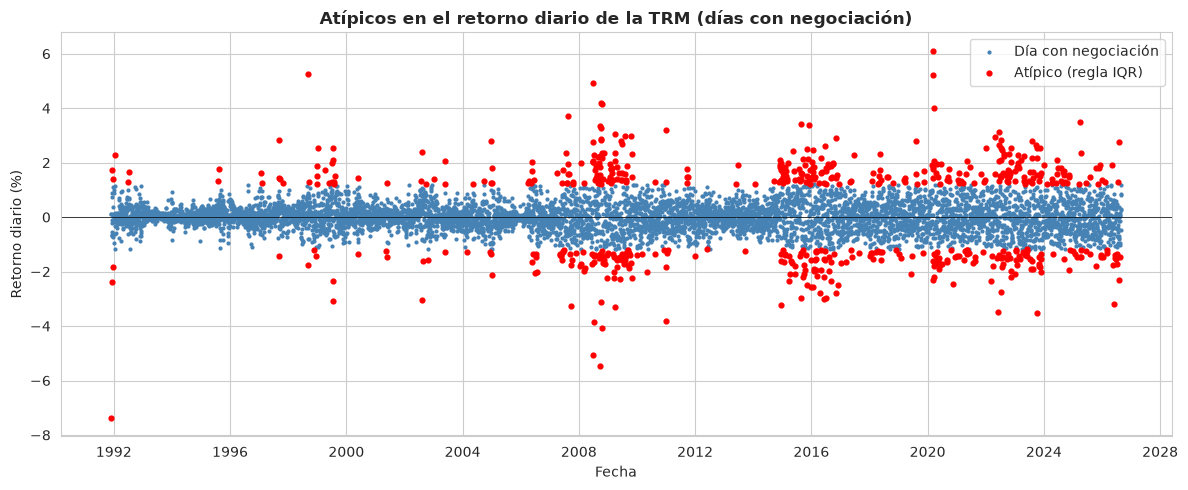

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
normales = negociacion[~negociacion["atipico"]]
atipicos = negociacion[negociacion["atipico"]]
ax.scatter(normales["fecha"], normales["retorno_diario"], s=4, color="steelblue", label="Día con negociación")
ax.scatter(atipicos["fecha"], atipicos["retorno_diario"], s=12, color="red", label="Atípico (regla IQR)")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Atípicos en el retorno diario de la TRM (días con negociación)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Retorno diario (%)")
ax.legend()
plt.tight_layout()
guardar(fig, "06_atipicos_retorno.png")
plt.show()

In [15]:
# Distribución temporal de los atípicos: el umbral IQR es único para toda la serie, por lo que conviene
# revisar si los marcados se reparten de forma pareja. Se consideran los años con al menos 100 días de negociación.
negociacion["año"] = negociacion["fecha"].dt.year
por_año = negociacion.groupby("año")["atipico"].agg(["mean", "size"])
por_año = por_año[por_año["size"] >= 100]["mean"] * 100

print("Años con mayor proporción de atípicos:")
print(por_año.nlargest(5).round(1).to_string())
print("\nAños con menor proporción de atípicos:")
print(por_año.nsmallest(5).round(1).to_string())

# Contraste entre regímenes cambiarios: la banda cambiaria rigió hasta el 25 de septiembre de 1999
banda = negociacion[negociacion["fecha"] < config.FIN_BANDA_CAMBIARIA]
flotacion = negociacion[negociacion["fecha"] >= config.FIN_BANDA_CAMBIARIA]
for nombre, tramo in [("Banda cambiaria", banda), ("Libre flotación", flotacion)]:
    print(f"\n{nombre}: {tramo['atipico'].mean() * 100:.1f}% atípicos | "
          f"desv. est. del retorno {tramo['retorno_diario'].std():.3f}")
print(f"\nRazón de volatilidades: {flotacion['retorno_diario'].std() / banda['retorno_diario'].std():.2f}")

Años con mayor proporción de atípicos:
año
2009    25.3
2008    24.4
2015    23.3
2016    22.7
2023    22.6

Años con menor proporción de atípicos:
año
1993    0.0
1994    0.0
1996    0.0
2000    0.8
1995    0.8

Banda cambiaria: 2.0% atípicos | desv. est. del retorno 0.451

Libre flotación: 9.1% atípicos | desv. est. del retorno 0.733

Razón de volatilidades: 1.62


**Interpretación:** A partir de los resultados podemos determinar que los atípicos no se distribuyen uniformemente en el tiempo, ya que en años como 2008, 2009, 2015 y 2016 más de una quinta parte de los días de negociación supera los límites, mientras que entre 1993 y 1996 la proporción es prácticamente nula. Adicionalmente, a pesar de que el gráfico por sí solo no nos permite determinar la causa de este comportamiento, el contraste por régimen cambiario nos ofrece una explicación razonable, ya que Colombia mantuvo un sistema de banda cambiaria hasta el 25 de septiembre de 1999, fecha desde la cual la tasa de cambio pasó a flotar libremente (Banco de la República, s.f.-d). Bajo el régimen de banda la autoridad intervenía para mantener la tasa dentro de unos límites, por ende, la variabilidad diaria era estructuralmente menor, lo que se refleja en la salida con un 2.0 % de atípicos y una desviación estándar del retorno de 0.451 frente al 9.1 % y 0.733 del período de libre flotación, es decir, una volatilidad 1.62 veces mayor. Teniendo en cuenta lo anterior, podemos concluir que aplicar un umbral único sobre una serie cuyo régimen de volatilidad cambió a mitad de período genera que la regla identifique en buena medida el cambio de régimen y no observaciones anómalas individuales, limitación que conviene tener presente al interpretar la proporción obtenida.

---
# 3. Estacionariedad

## 3.1 Log-retorno

Retomando lo evidenciado en las secciones anteriores, tanto el nivel como la dispersión de la serie cambian a lo largo del período, por lo que corresponde evaluar formalmente si la serie es estacionaria. Para realizar estas pruebas se hizo uso del log-retorno, que corresponde a la primera diferencia del logaritmo de la serie, y no de la variación porcentual simple calculada en la sección 1. Para justificarlo hacemos uso de la hipótesis de caminata aleatoria que se asocia a la eficiencia de mercado (Fama, 1970), según la cual el precio de un activo en un mercado eficiente sigue un proceso de la forma $\log P_t = \log P_{t-1} + \varepsilon_t$, donde $\varepsilon_t$ corresponde a un término de ruido blanco. Teniendo esto en cuenta, el nivel es no estacionario por construcción, ya que constituye una suma acumulada de choques, mientras que su primera diferencia sí satisface las condiciones de estacionariedad débil. Además, el log-retorno es aditivo en el tiempo, propiedad que la variación porcentual simple no posee.

In [16]:
trm["log_retorno"] = np.log(trm["trm"]).diff() * 100

comparacion = trm[["fecha", "retorno_diario", "log_retorno"]].dropna()
print("Día de mayor movimiento absoluto:")
print(comparacion.loc[comparacion["retorno_diario"].abs().idxmax()].to_string())
print("\nUn día típico (movimiento pequeño):")
print(comparacion.iloc[100].to_string())

Día de mayor movimiento absoluto:
fecha             1991-12-01 00:00:00
retorno_diario              -7.381604
log_retorno                  -7.66824

Un día típico (movimiento pequeño):
fecha             1992-03-07 00:00:00
retorno_diario              -0.080097
log_retorno                 -0.080129


**Interpretación:** En los resultados se puede observar que en jornadas de variación reducida ambas medidas resultan prácticamente equivalentes, con diferencias inferiores a una milésima porcentual, mientras que en la observación de mayor movimiento absoluto la divergencia es apreciable, con -7.38 % frente a -7.67 %. Lo anterior se debe a que la aproximación entre ambas se deteriora a medida que aumenta la magnitud del cambio, razón por la cual se trabaja con el log-retorno en las pruebas que siguen.

## 3.2 Media y desviación móvil

Previo a realizar las pruebas formales se hizo uso de una ventana móvil de 365 observaciones para inspeccionar la media y la desviación estándar de la serie, con la finalidad de evaluar de forma visual las dos primeras condiciones de estacionariedad débil, es decir, que la media y la varianza se mantengan constantes en el tiempo.

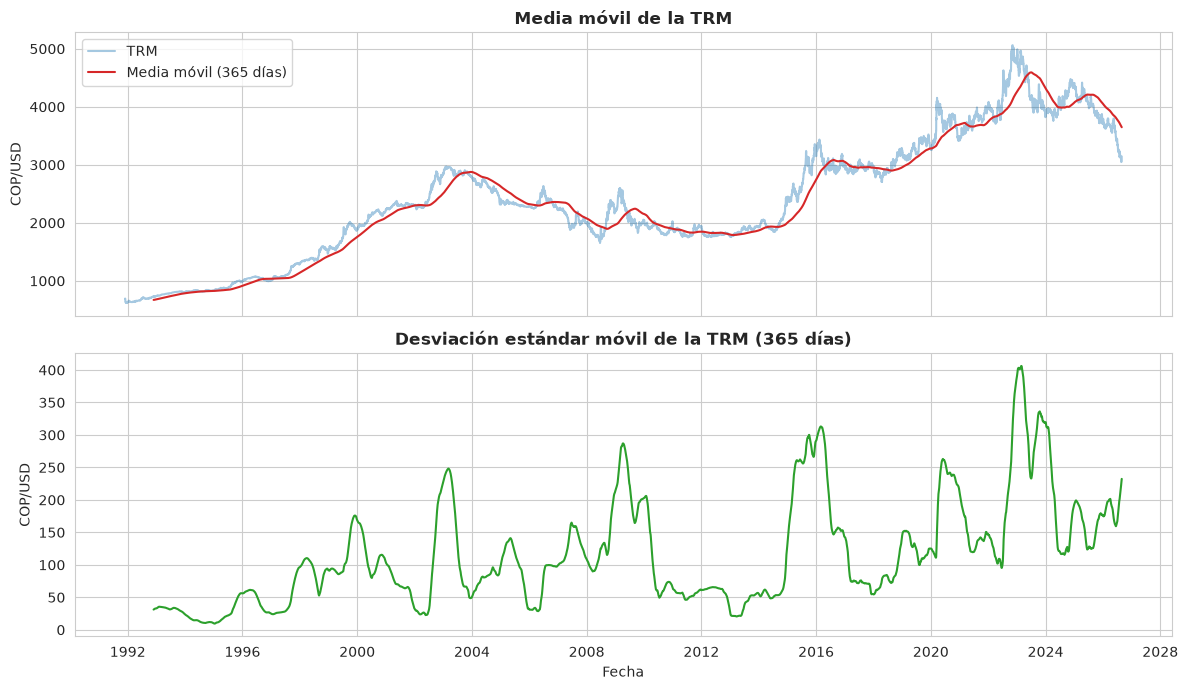

In [17]:
media_movil = trm["trm"].rolling(window=365).mean()
std_movil = trm["trm"].rolling(window=365).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(trm["fecha"], trm["trm"], color=AZUL, alpha=0.4, label="TRM")
axes[0].plot(trm["fecha"], media_movil, color=ROJO, label="Media móvil (365 días)")
axes[0].set_title("Media móvil de la TRM")
axes[0].set_ylabel("COP/USD")
axes[0].legend()

axes[1].plot(trm["fecha"], std_movil, color=VERDE)
axes[1].set_title("Desviación estándar móvil de la TRM (365 días)")
axes[1].set_ylabel("COP/USD")
axes[1].set_xlabel("Fecha")

plt.tight_layout()
guardar(fig, "07_media_desviacion_movil.png")
plt.show()

**Interpretación:** En el panel superior de la gráfica se puede observar que la media móvil reproduce la trayectoria de la serie en lugar de mantenerse constante, lo cual constituye evidencia directa del incumplimiento de la primera condición de estacionariedad débil. Por otro lado, en el panel inferior la desviación estándar móvil tampoco es constante, ya que presenta máximos locales con valores que oscilan aproximadamente entre 10 y 400 COP/USD, a partir de lo cual podemos anticipar que las pruebas formales de la sección siguiente no permitirán aceptar la estacionariedad de la serie en nivel.

## 3.3 Pruebas formales: ADF y KPSS

Las pruebas se aplican sobre el nivel, el logaritmo y la primera diferencia del logaritmo. Se debe tener en cuenta que ambas pruebas plantean hipótesis nulas opuestas, ya que por un lado la prueba de Dickey-Fuller aumentada evalúa la presencia de una raíz unitaria como hipótesis nula, de tal forma que un p-valor inferior a 0.05 permite concluir estacionariedad (Dickey & Fuller, 1979), mientras que la prueba KPSS invierte el planteamiento y toma la estacionariedad como hipótesis nula, por lo que un p-valor inferior a 0.05 indica lo contrario (Kwiatkowski et al., 1992). La aplicación conjunta de ambas reduce el riesgo de conclusiones erróneas derivadas de la baja potencia de cada prueba de forma aislada, y por esta razón la función `pruebas.estacionariedad` solo clasifica una serie como estacionaria cuando ambas coinciden.

| Prueba | $H_0$ | $H_1$ | Conclusión si se rechaza $H_0$ |
|---|---|---|---|
| **ADF** | La serie tiene raíz unitaria | La serie es estacionaria | Estacionaria |
| **KPSS** | La serie es estacionaria | La serie tiene raíz unitaria | No estacionaria |

In [18]:
log_trm = np.log(trm["trm"])
tabla_estacionariedad = pd.DataFrame([
    pruebas.estacionariedad(trm["trm"], "TRM (nivel)"),
    pruebas.estacionariedad(log_trm, "log(TRM)"),
    pruebas.estacionariedad(trm["log_retorno"], "Log-retorno"),
])
print(tabla_estacionariedad.to_string(index=False))

      Serie  ADF estadístico ADF p-valor  KPSS estadístico KPSS p-valor      Conclusión
TRM (nivel)          -1.5661      0.5006           13.5358       < 0.01 no estacionaria
   log(TRM)          -2.6129      0.0904           13.1370       < 0.01 no estacionaria
Log-retorno         -20.3830      0.0000            0.4163       0.0701    estacionaria


**Interpretación:** En la salida observamos que ambas pruebas coinciden al clasificar la serie en nivel como no estacionaria, ya que la prueba ADF no rechaza la hipótesis nula de raíz unitaria con un p-valor de 0.5006, mientras que KPSS rechaza la hipótesis nula de estacionariedad con un p-valor inferior a 0.01, convergencia que confirma lo evidenciado previamente en el análisis gráfico. Por otro lado, la transformación logarítmica no modifica la conclusión, ya que ambas pruebas mantienen el diagnóstico de no estacionariedad con p-valores de 0.0904 en ADF y menor a 0.01 en KPSS, lo cual se debe a que el logaritmo estabiliza la varianza al comprimir proporcionalmente las variaciones de mayor magnitud, pero no elimina el componente tendencial, que es la fuente principal del incumplimiento de las condiciones de estacionariedad en esta serie.

Finalmente, al aplicar una única diferencia sobre la serie logarítmica ambas pruebas coinciden esta vez en clasificar la serie como estacionaria, ya que ADF rechaza la raíz unitaria con un p-valor de 0.0000 y KPSS no rechaza la estacionariedad con un p-valor de 0.0701. Este resultado es consistente con la hipótesis de caminata aleatoria descrita previamente (Fama, 1970), bajo la cual un precio de mercado se caracteriza como un proceso integrado de orden uno.

---
# 4. Funciones de autocorrelación (ACF y PACF)

Teniendo en cuenta la transformación que permite volver la serie estacionaria, solo hace falta verificar el resultado mediante las funciones de autocorrelación. Por un lado, la función de autocorrelación mide la correlación entre la serie y sus rezagos, incluyendo los efectos que se transmiten a través de los rezagos intermedios, mientras que por otro lado la función de autocorrelación parcial aísla la correlación directa al controlar el efecto de dichos rezagos. En este caso no se replica el análisis sobre el logaritmo de la serie de forma independiente, ya que su ACF coincide con la de la serie en nivel hasta la cuarta cifra decimal, por lo que se contrastan únicamente el nivel y el log-retorno.

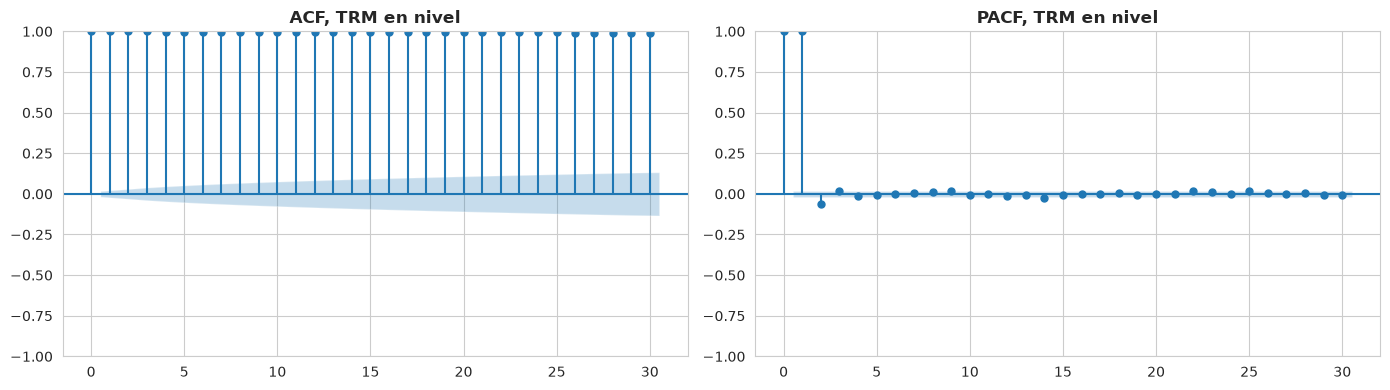

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(trm["trm"], lags=30, ax=axes[0])
axes[0].set_title("ACF, TRM en nivel")
plot_pacf(trm["trm"], lags=30, ax=axes[1])
axes[1].set_title("PACF, TRM en nivel")
plt.tight_layout()
guardar(fig, "08_acf_pacf_nivel.png")
plt.show()

**Interpretación:** En el gráfico logramos observar que la ACF no decae dentro de los treinta rezagos considerados y se mantiene próxima a la unidad en todo el rango, comportamiento característico de una serie no estacionaria (Box et al., 2015). Por otro lado, la PACF presenta un único coeficiente significativo en el primer rezago, con valores cercanos a cero en los rezagos posteriores, configuración propia de un proceso autorregresivo de primer orden con coeficiente próximo a uno, es decir, de una caminata aleatoria.

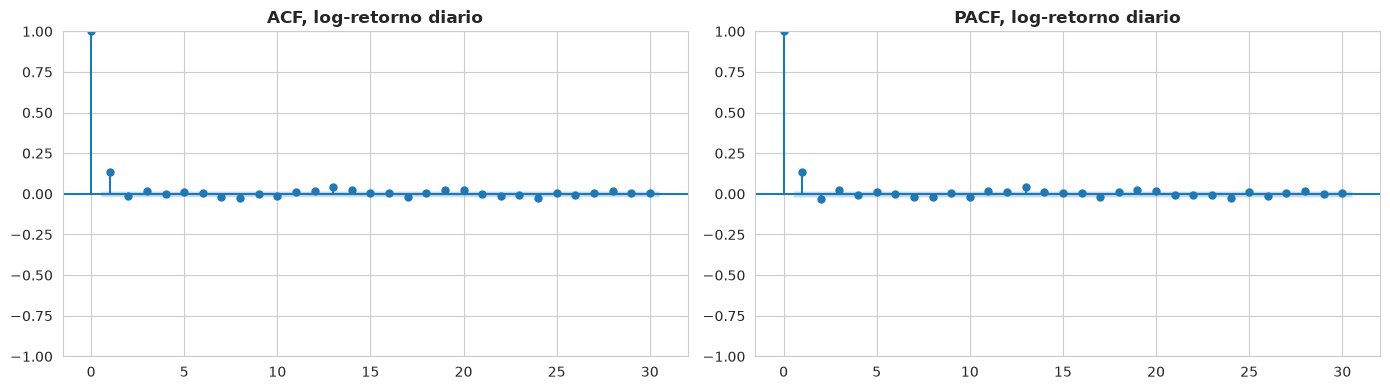

Umbral de significancia: ±0.0174

 rezago     ACF    PACF ACF signif. PACF signif.
      1  0.1330  0.1330          Sí           Sí
      2 -0.0111 -0.0293          No           Sí
      7 -0.0165 -0.0163          No           No
     14  0.0249  0.0135          Sí           No
     21 -0.0038 -0.0063          No           No
     28  0.0205  0.0188          Sí           Sí


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(trm["log_retorno"].dropna(), lags=30, ax=axes[0])
axes[0].set_title("ACF, log-retorno diario")
plot_pacf(trm["log_retorno"].dropna(), lags=30, ax=axes[1])
axes[1].set_title("PACF, log-retorno diario")
plt.tight_layout()
guardar(fig, "09_acf_pacf_log_retorno.png")
plt.show()

tabla_diaria = pruebas.tabla_autocorrelacion(trm["log_retorno"].dropna(), [1, 2, 7, 14, 21, 28])
print(f"Umbral de significancia: ±{pruebas.banda(trm['log_retorno'].notna().sum()):.4f}\n")
print(tabla_diaria.to_string(index=False))

**Interpretación:** En este caso tanto la ACF como la PACF decaen a valores próximos a cero inmediatamente después del primer rezago, cuyo coeficiente de 0.1330 es el único de magnitud apreciable y cuyo origen se discute en el notebook 02. A partir de allí no se observan coeficientes sistemáticamente relevantes, comportamiento que se aproxima al de un proceso de ruido blanco, resultado esperado bajo la hipótesis de eficiencia de mercado (Fama, 1970) y consistente con la ausencia de autocorrelación lineal reportada como hecho estilizado de los retornos financieros (Cont, 2001).

Adicionalmente, en los rezagos 7, 14, 21 y 28, donde se esperaría encontrar la huella del ciclo semanal identificado previamente, el rezago 7, que sería el más directo, no resulta significativo, y aunque los rezagos 14 y 28 superan el umbral, sus valores de 0.0249 y 0.0205 explican menos del 0.1 % de la varianza, lo cual confirma que dicho ciclo obedece a la regla de publicación de la serie y no a una estructura de dependencia temporal aprovechable. Lo anterior se debe a que con más de 12 000 observaciones el umbral de significancia es de apenas ±0.0174, de modo que coeficientes de magnitud despreciable resultan significativos, dificultad que se retoma en el notebook 02 al elegir la frecuencia de modelado. Finalmente, el contraste entre ambos gráficos sintetiza el resultado central de esta etapa, ya que la TRM en nivel constituye una serie no estacionaria, mientras que su primera diferencia logarítmica sí satisface las condiciones de estacionariedad débil.

---
# 5. Conclusiones de la etapa

| Aspecto | Resultado |
|---|---|
| Calidad | 12 694 observaciones diarias entre el 27/11/1991 y el 28/08/2026, sin duplicados, nulos ni días faltantes |
| Tendencia | Creciente de largo plazo, con episodios de depreciación acelerada y correcciones parciales |
| Estacionalidad | Sin efecto calendario mensual. El único patrón periódico es semanal y administrativo: el 34.6 % de los retornos diarios son exactamente cero por la regla de publicación |
| Descomposición | Modelo multiplicativo con período 7, con un componente estacional de apenas ±0.04 % |
| Atípicos | 7.50 % de los días con negociación, frente al 0.70 % esperado bajo normalidad. La proporción pasa de 2.0 % en la banda cambiaria a 9.1 % en libre flotación |
| Estacionariedad | Nivel y logaritmo no estacionarios según ADF y KPSS. El log-retorno es estacionario (ADF p = 0.0000; KPSS p = 0.0701) |

En conjunto, la TRM se comporta como un proceso integrado de orden uno cuyo log-retorno diario se aproxima al ruido blanco, con colas pesadas y agrupamiento de volatilidad. Sin embargo, dos características de la serie diaria condicionan la etapa siguiente, ya que por un lado la regla de publicación introduce retornos nulos que no corresponden a jornadas de negociación, y por otro lado el tamaño muestral vuelve significativas autocorrelaciones de magnitud despreciable. Por esta razón, en el notebook 02 el modelado se realiza sobre el promedio mensual de la TRM.

---
# Referencias

Banco de la República. (2018). *Circular Reglamentaria Externa DODM-146. Asunto 8: Metodología de cálculo de la tasa de cambio representativa del mercado*. https://www.banrep.gov.co/sites/default/files/reglamentacion/archivos/dodm146-25052018.pdf

Banco de la República. (2026). *Tasa Representativa del Mercado (TRM). Serie diaria 1991-2026* [Conjunto de datos]. Portal de Estadísticas Económicas. https://suameca.banrep.gov.co/estadisticas-economicas/

Banco de la República. (s.f.-a). *Tasa de cambio o tasa de cambio representativa del mercado (TRM)* [Glosario]. Recuperado el 30 de agosto de 2026, de https://www.banrep.gov.co/es/glosario/tasa-cambio-trm

Banco de la República. (s.f.-b). *Box 1: Recent performance of the exchange rate in Colombia*. Inflation Report. Recuperado el 30 de agosto de 2026, de https://www.banrep.gov.co/en/publications/inflation-report/box-1-recent-performance-of-the-exchange-rate-in-colombia

Banco de la República. (s.f.-c). *Pass-through of the exchange rate to core inflation in Colombia: An analysis of time-varying parameters*. Recuperado el 30 de agosto de 2026, de https://www.banrep.gov.co/en/pass-through-exchange-rate-core-inflation-colombia-analysis-time-varying-parameters

Banco de la República. (s.f.-d). *Banda cambiaria* [Enciclopedia]. Red Cultural del Banco de la República. Recuperado el 31 de agosto de 2026, de https://enciclopedia.banrepcultural.org/index.php/Banda_cambiaria

Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2015). *Time series analysis: Forecasting and control* (5.ª ed.). Wiley.

Cont, R. (2001). Empirical properties of asset returns: Stylized facts and statistical issues. *Quantitative Finance, 1*(2), 223–236.

Dickey, D. A., & Fuller, W. A. (1979). Distribution of the estimators for autoregressive time series with a unit root. *Journal of the American Statistical Association, 74*(366), 427–431.

Fama, E. F. (1970). Efficient capital markets: A review of theory and empirical work. *The Journal of Finance, 25*(2), 383–417.

Kwiatkowski, D., Phillips, P. C. B., Schmidt, P., & Shin, Y. (1992). Testing the null hypothesis of stationarity against the alternative of a unit root: How sure are we that economic time series have a unit root? *Journal of Econometrics, 54*(1–3), 159–178.

Mandelbrot, B. (1963). The variation of certain speculative prices. *The Journal of Business, 36*(4), 394–419.

Seabold, S., & Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. *Proceedings of the 9th Python in Science Conference*, 92–96.

Tukey, J. W. (1977). *Exploratory data analysis*. Addison-Wesley.